Saving building.jpg to building.jpg


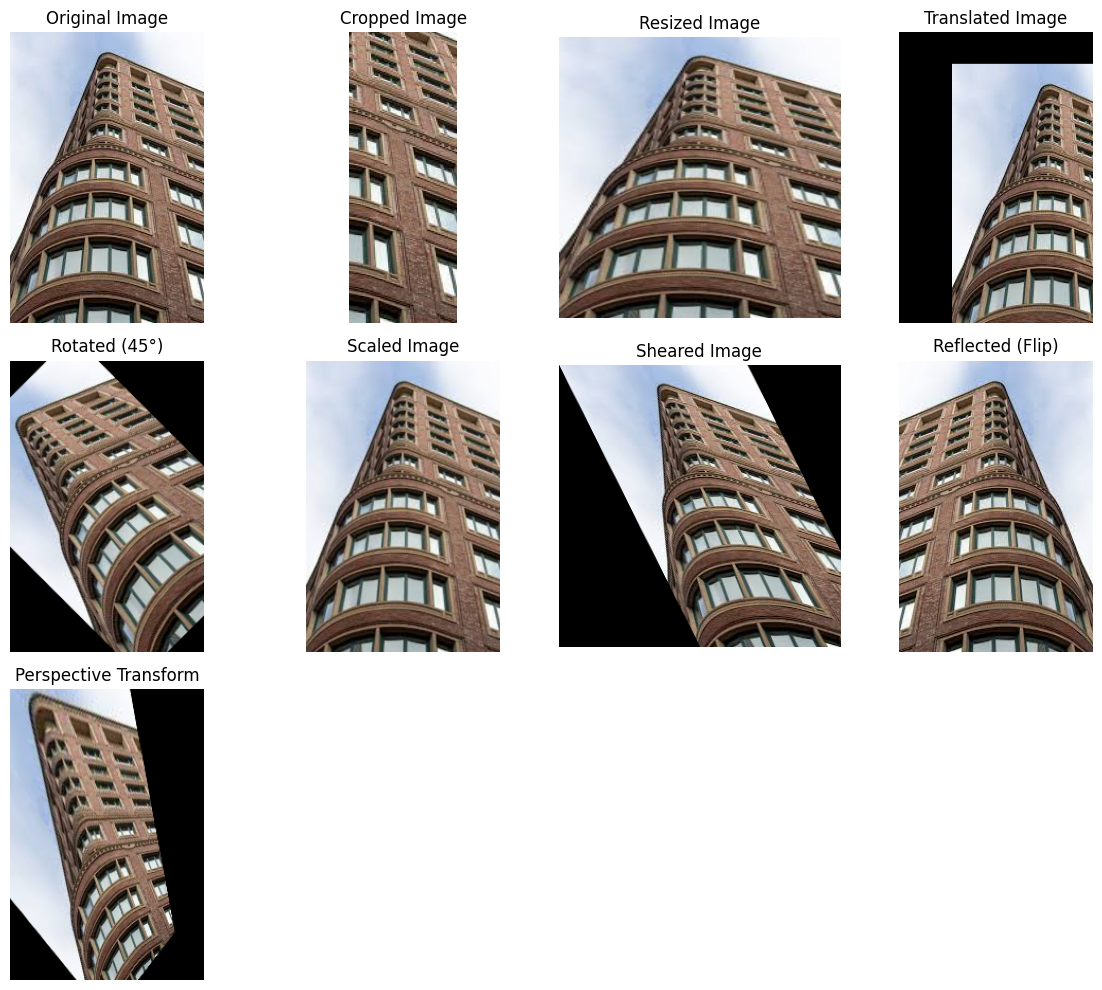

In [ ]:
from google.colab import files
uploaded = files.upload()

import cv2
import numpy as np
import matplotlib.pyplot as plt

img_name = list(uploaded.keys())[0]
img = cv2.imread(img_name)

assert img is not None, "Image not found!"

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 10))

plt.subplot(3, 4, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

cropped = img[50:300, 100:400]
cropped_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)

plt.subplot(3, 4, 2)
plt.imshow(cropped_rgb)
plt.title("Cropped Image")
plt.axis("off")

resized = cv2.resize(img, (300, 300))
resized_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)

plt.subplot(3, 4, 3)
plt.imshow(resized_rgb)
plt.title("Resized Image")
plt.axis("off")

rows, cols = img.shape[:2]

M_trans = np.float32([[1, 0, 50], [0, 1, 30]])
translated = cv2.warpAffine(img, M_trans, (cols, rows))
translated_rgb = cv2.cvtColor(translated, cv2.COLOR_BGR2RGB)

plt.subplot(3, 4, 4)
plt.imshow(translated_rgb)
plt.title("Translated Image")
plt.axis("off")

center = (cols // 2, rows // 2)
M_rot = cv2.getRotationMatrix2D(center, 45, 1.0)
rotated = cv2.warpAffine(img, M_rot, (cols, rows))
rotated_rgb = cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB)

plt.subplot(3, 4, 5)
plt.imshow(rotated_rgb)
plt.title("Rotated (45°)")
plt.axis("off")

scaled = cv2.resize(img, None, fx=1.5, fy=1.5)
scaled_rgb = cv2.cvtColor(scaled, cv2.COLOR_BGR2RGB)

plt.subplot(3, 4, 6)
plt.imshow(scaled_rgb)
plt.title("Scaled Image")
plt.axis("off")

M_shear = np.float32([[1, 0.5, 0], [0, 1, 0]])
sheared = cv2.warpAffine(img, M_shear, (int(cols * 1.5), rows))
sheared_rgb = cv2.cvtColor(sheared, cv2.COLOR_BGR2RGB)

plt.subplot(3, 4, 7)
plt.imshow(sheared_rgb)
plt.title("Sheared Image")
plt.axis("off")

flipped = cv2.flip(img, 1)
flipped_rgb = cv2.cvtColor(flipped, cv2.COLOR_BGR2RGB)

plt.subplot(3, 4, 8)
plt.imshow(flipped_rgb)
plt.title("Reflected (Flip)")
plt.axis("off")

pts1 = np.float32([
    [50, 50],
    [cols - 50, 50],
    [50, rows - 50],
    [cols - 50, rows - 50]
])

pts2 = np.float32([
    [10, 100],
    [cols - 100, 50],
    [100, rows - 10],
    [cols - 50, rows - 50]
])

M_persp = cv2.getPerspectiveTransform(pts1, pts2)
perspective = cv2.warpPerspective(img, M_persp, (cols, rows))
perspective_rgb = cv2.cvtColor(perspective, cv2.COLOR_BGR2RGB)

plt.subplot(3, 4, 9)
plt.imshow(perspective_rgb)
plt.title("Perspective Transform")
plt.axis("off")

plt.tight_layout()
plt.show()

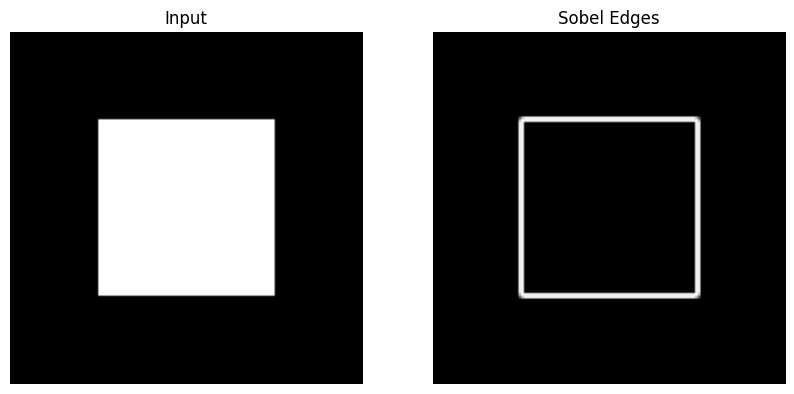

In [ ]:
import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt

def sobel_edge_detection(image):
    sx = np.array([[-1, 0, 1],
                   [-2, 0, 2],
                   [-1, 0, 1]])

    sy = np.array([[-1,-2,-1],
                   [ 0, 0, 0],
                   [ 1, 2, 1]])

    Ix = ndimage.convolve(image, sx, mode='constant')
    Iy = ndimage.convolve(image, sy, mode='constant')

    magnitude = np.hypot(Ix, Iy)
    return magnitude / magnitude.max()

img = np.zeros((128, 128))
img[32:96, 32:96] = 1.0

edges = sobel_edge_detection(img)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Input")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(edges, cmap='gray')
plt.title("Sobel Edges")
plt.axis("off")

plt.show()

Detected lines (rho, theta): [(np.float64(0.0), np.float64(-0.7853981633974483))]


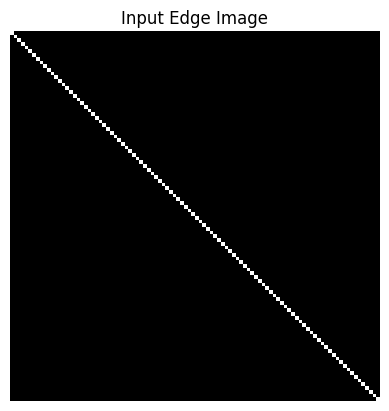

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def hough_line_detection(binary_edges, theta_step=0.5, threshold_ratio=0.6):
    h, w = binary_edges.shape
    diag = int(np.ceil(np.hypot(h, w)))

    rhos = np.linspace(-diag, diag, 2*diag + 1)
    thetas = np.deg2rad(np.arange(-90, 90, theta_step))

    accumulator = np.zeros((len(rhos), len(thetas)), dtype=int)

    y, x = np.nonzero(binary_edges > 0.1)

    for px, py in zip(x, y):
        for t_idx, theta in enumerate(thetas):
            rho = px * np.cos(theta) + py * np.sin(theta)
            rho_idx = np.argmin(np.abs(rhos - rho))
            accumulator[rho_idx, t_idx] += 1

    max_votes = accumulator.max()
    peaks = np.argwhere(accumulator >= threshold_ratio * max_votes)

    lines = []
    for rho_idx, theta_idx in peaks:
        lines.append((rhos[rho_idx], thetas[theta_idx]))

    return lines, accumulator

img = np.zeros((100, 100))
for i in range(100):
    img[i, i] = 1.0

lines, acc = hough_line_detection(img)

print("Detected lines (rho, theta):", lines)

plt.imshow(img, cmap='gray')
plt.title("Input Edge Image")
plt.axis("off")
plt.show()

Saving chess.png to chess.png


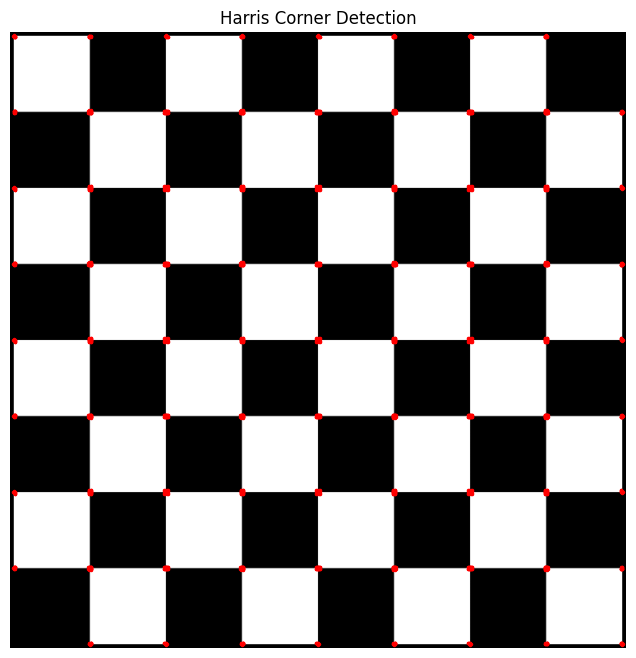

In [ ]:
from google.colab import files
uploaded = files.upload()

import numpy as np
import cv2
from scipy import ndimage
import matplotlib.pyplot as plt

img_name = list(uploaded.keys())[0]
img = cv2.imread(img_name)

if img is None:
    print("Error: Image not loaded")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = gray / 255.0

    def harris_corners(gray, sigma=1.0, k=0.05, thresh=0.01):
        Ix = ndimage.sobel(gray, axis=1)
        Iy = ndimage.sobel(gray, axis=0)

        Ix2 = ndimage.gaussian_filter(Ix**2, sigma)
        Iy2 = ndimage.gaussian_filter(Iy**2, sigma)
        Ixy = ndimage.gaussian_filter(Ix*Iy, sigma)

        det = Ix2 * Iy2 - Ixy**2
        trace = Ix2 + Iy2
        R = det - k * trace**2

        corners = np.argwhere(R > thresh * R.max())
        return corners

    corners = harris_corners(gray)

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8,8))
    plt.imshow(img_rgb)
    plt.plot(corners[:,1], corners[:,0], 'r.', markersize=3)
    plt.title("Harris Corner Detection")
    plt.axis("off")
    plt.show()